In [ ]:
# Hosted D2L setup: fetch the exact helper module used to build this notebook.
from pathlib import Path
from urllib.request import urlretrieve
from importlib.metadata import PackageNotFoundError, version
import importlib.util, os, subprocess, sys

required = ['numpy', 'pandas', 'matplotlib', 'requests', 'scipy', 'pillow', 'regex', 'jax', 'jaxlib', 'flax', 'optax', 'orbax-checkpoint', 'tensorflow', 'protobuf', 'ml-dtypes']
imports = {'pillow': 'PIL', 'orbax-checkpoint': 'orbax', 'protobuf': 'google.protobuf', 'ml-dtypes': 'ml_dtypes'}
pinned = {'jax': ('0.10.2', 'jax==0.10.2', 'jax[cuda12]==0.10.2', 'exact'), 'jaxlib': ('0.10.2', 'jaxlib==0.10.2', 'jaxlib==0.10.2', 'exact'), 'flax': ('0.12.7', 'flax==0.12.7', 'flax==0.12.7', 'exact'), 'optax': ('0.2.8', 'optax==0.2.8', 'optax==0.2.8', 'exact'), 'orbax-checkpoint': ('0.12.0', 'orbax-checkpoint==0.12.0', 'orbax-checkpoint==0.12.0', 'exact')}
fallbacks = {'tensorflow': 'tensorflow==2.21.0', 'protobuf': 'protobuf==7.34.1', 'ml-dtypes': 'ml-dtypes==0.5.4'}
device = os.environ.get("D2L_HOSTED_DEVICE", "auto").lower()
if device not in ("auto", "cpu", "gpu"):
    raise ValueError(f"Invalid D2L_HOSTED_DEVICE={device!r}")
if device == "auto":
    try:
        gpu = (Path("/dev/nvidia0").exists() or
               subprocess.run(["nvidia-smi", "-L"], capture_output=True,
                              timeout=5).returncode == 0)
    except (FileNotFoundError, subprocess.SubprocessError):
        gpu = False
else:
    gpu = device == "gpu"
if not gpu:
    os.environ.setdefault("CUDA_VISIBLE_DEVICES", "-1")
    os.environ.setdefault("JAX_PLATFORMS", "cpu")
tensorflow_version = None
if 'jax' in ("tensorflow", "jax"):
    try:
        tensorflow_version = version("tensorflow")
    except PackageNotFoundError:
        pass
# Colab's CPU image currently carries a CUDA-enabled TensorFlow wheel. Its
# first ordinary tensor operation probes CUDA and emits an error-level cuInit
# diagnostic. JAX notebooks also use TensorFlow for data loading, so overlay
# the matching CPU build in both CPU variants. Keep the provider's
# ``tensorflow`` distribution metadata: other preinstalled Colab packages
# depend on that distribution name, while both wheels expose the same module.
if not gpu and 'jax' in ("tensorflow", "jax"):
    try:
        tensorflow_cpu_version = version("tensorflow-cpu")
    except PackageNotFoundError:
        tensorflow_cpu_version = None
    if (tensorflow_version is not None and
            tensorflow_cpu_version != tensorflow_version):
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "-q", "--no-deps",
            f"tensorflow-cpu=={tensorflow_version}",
        ])
if "tf-keras" in fallbacks and tensorflow_version is not None:
    fallbacks["tf-keras"] = f"tf-keras=={tensorflow_version}"
missing = []
for package in required:
    if package in pinned:
        wanted, cpu_requirement, gpu_requirement, match = pinned[package]
        requirement = gpu_requirement if gpu else cpu_requirement
        try:
            installed = version(package)
        except PackageNotFoundError:
            installed = None
        actual = (installed.split("+", 1)[0]
                  if installed is not None and match == "public" else installed)
        if actual != wanted:
            missing.append(requirement)
    elif importlib.util.find_spec(imports.get(package, package)) is None:
        missing.append(fallbacks.get(package, package))
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

mismatched = []
for package, (wanted, _, _, match) in pinned.items():
    try:
        installed = version(package)
    except PackageNotFoundError:
        installed = None
    actual = (installed.split("+", 1)[0]
              if installed is not None and match == "public" else installed)
    if actual != wanted:
        mismatched.append(f"{package}={installed!r} (expected {wanted})")
if mismatched:
    raise RuntimeError("Hosted runtime setup failed: " + ", ".join(mismatched))

root = Path(".d2l-hosted") / "0114bae219d4d94bc9d18a2e1ab76c089e2dc890"
package = root / "d2l"
package.mkdir(parents=True, exist_ok=True)
base = "https://raw.githubusercontent.com/smolix/d2l-neu/0114bae219d4d94bc9d18a2e1ab76c089e2dc890/d2l"
for name in ('__init__.py', 'jax.py'):
    target = package / name
    if not target.exists():
        urlretrieve(f"{base}/{name}", target)
if str(root.resolve()) not in sys.path:
    sys.path.insert(0, str(root.resolve()))
pythonpath = os.environ.get("PYTHONPATH", "").split(os.pathsep)
if str(root.resolve()) not in pythonpath:
    os.environ["PYTHONPATH"] = os.pathsep.join(
        [str(root.resolve()), *[entry for entry in pythonpath if entry]]
    )


# Relativistic Objectives

that section kept the critic's task fixed while varying its loss. A relativistic critic makes the complementary change: it assigns scalar scores as before, but evaluates the difference between the scores of one real and one generated sample. We derive the value of this pairing objective at the optimal critic by reducing it to the log-loss game of that section. The resulting value is the Jensen--Shannon divergence between the two possible orderings of a real--generated pair. Pairing also replaces the generator's threshold-based update weight with a rank statistic, which changes the loss landscape. This property motivates the R3GAN objective [@Huang.Gokaslan.Kuleshov.ea.2024], developed further in that section and tested on images in that section. Pairing does not, however, prevent saturation on disjoint supports.

In [1]:
%matplotlib inline
from d2l import jax as d2l
import numpy as np

## Scoring Pairs

The construction is due to @Jolicoeur-Martineau.2019, who called the resulting critic *relativistic*: it scores a sample relative to a sample from the opposing distribution rather than against an absolute standard. The paired form used here is abbreviated RpGAN, for relativistic *paired*, and the divergence derived below inherits the subscript. We keep the notation of that section: data density $p$, generator density $q$, ratio $\rho = p/q$, log ratio $\lambda = \log \rho$, and a critic $D$ whose value is a realness logit. Draw a real sample $x \sim p$ and a generated sample $x' \sim q$ independently, and score the pair by the difference of the two critic values:

$$
\Phi(D) \;=\; E_{x \sim p,\; x' \sim q}\big[\log \sigma\big(D(x) - D(x')\big)\big].
$$

The critic maximizes $\Phi$, whereas the generator minimizes it. The quantity $\sigma(D(x) - D(x'))$ is the critic's probability that the pair is correctly ordered, with the real sample ranked above the generated sample. Thus the critic maximizes the log probability of the correct order, while the generator reduces the critic's ability to distinguish the order.

The probability model in the equation is the Bradley--Terry model [@Bradley.Terry.1952]. Under the score function $D$, it assigns probability $\sigma(D(x) - D(x'))$ to preferring $x$ over $x'$. Section that section uses the same comparison model in the equation to fit reward models from human preferences. Here $\Phi$ is the pairwise logistic log-likelihood of ranking real samples above generated ones, so the critic learns a ranking rather than a classification rule. Elo-style evaluations of generative models use the same construction at the model level by fitting Bradley--Terry scores to pairwise human votes.

Ranking introduces an additive-shift symmetry absent from the classification objective. the figure compares the two uses of the critic scores.

![Scoring one sample against a threshold versus scoring a pair by its difference. On the left, the classical critic's verdict depends on whether $D(x)$ clears a fixed level, so adding a constant $b$ to every score changes the verdict. On the right, the pairing critic compares two scores, and the same shift moves both members together and leaves the difference $D(x) - D(x')$ unchanged.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/mdl-gan-pairing.svg)

Formally, replacing $D$ by $D + b$ for any constant $b$ leaves every score difference, and therefore $\Phi$, unchanged. The pairing game consequently identifies the critic only up to an additive constant. By contrast, the classical game of that section determines this constant as well; shifting its optimal critic strictly decreases the objective, as Exercise 1 shows. This invariance also appears in the equilibrium condition of @Huang.Gokaslan.Kuleshov.ea.2024, which requires only that the critic be constant on the support of the data. The paper uses $D$ as a fakeness logit, so its equations match ours after the substitution $D \mapsto -D$. The released implementation already uses the realness convention adopted here.

The objective also depends differently on the two distributions. The expectation in the equation is taken under the product measure $p \otimes q$, making $\Phi$ quadratic rather than affine in $(p, q)$. The objectives in that section were suprema of functionals affine in $(p, q)$, a property used to establish pointwise decoupling, joint convexity, and their interpretation as f-divergences. Those results do not apply directly to the pairing game, whose value we now compute.

## The Value of the Pairing Game

### The Optimal Critic

The inner maximization no longer decouples across points, because each critic value $D(t)$ interacts with every other through the differences. Concavity substitutes for decoupling.

**Proposition.** *$\Phi$ is concave in $D$, and if $p$ and $q$ share a common support it is maximized at $D^\star = \lambda$, uniquely up to an additive constant.*

**Proof.** The map $D \mapsto D(x) - D(x')$ is linear and $\log \sigma$ is concave, so the integrand of the equation is concave in $D$ for every pair, and the expectation preserves concavity; a stationary point is therefore a global maximum. Perturbing $D$ at a single point $t$, that point enters $\Phi$ once as the real member of a pair and once, with opposite sign, as the generated member, and $\tfrac{d}{du} \log \sigma(u) = \sigma(-u)$ gives the functional derivative

$$
\frac{\delta \Phi}{\delta D(t)}
\;=\; p(t)\, E_{x' \sim q}\big[\sigma(D(x') - D(t))\big]
\;-\; q(t)\, E_{x \sim p}\big[\sigma(D(t) - D(x))\big].
$$

At $D = \lambda$, we have $\sigma(\lambda(x') - \lambda(t)) = \rho(x')/(\rho(x') + \rho(t))$. The identity $q\rho = p$ converts the first term of the equation to $p(t) \int p(x')/(\rho(x') + \rho(t))\, dx'$. It converts the second to $q(t)\, \rho(t) \int p(x)/(\rho(t) + \rho(x))\, dx$, which is the same expression because $q(t)\rho(t)=p(t)$. The derivative therefore vanishes everywhere, so $\lambda$ is a maximizer. Strict concavity of $\log \sigma$ in the score differences makes this maximizer unique up to an additive shift. $\blacksquare$

The ranking and classification objectives estimate the same log density ratio. Equation the equation gives $D^\star = \lambda$ for the log-loss classifier, and the pairing objective gives the same result up to its undetermined additive constant. Replacing classification with ranking therefore preserves both the optimal critic and, as the theorem below confirms, the fixed point $q = p$. It changes the value and the shape of the objective away from that fixed point.

### The Lifted Game

$\Phi$ is the expectation of a fixed function of the pair $(x, x')$ under $p \otimes q$, which suggests treating the pair itself as the observation. Let $P = p \otimes q$ and $Q = q \otimes p$ denote the two orderings of an independent real--fake pair, viewed as distributions on $\mathcal{X} \times \mathcal{X}$: under $P$ the real sample sits first, under $Q$ it sits second. These two distributions can play the log-loss game of that section on the pair space, with a pair critic $\mathcal{D}: \mathcal{X} \times \mathcal{X} \to \mathbb{R}$ in place of $D$ and the value function $V_{P,Q}(\mathcal{D})$ given by the equation with $(P, Q)$ substituted for $(p, q)$. The following lemma connects that game to $\Phi$.

**Lemma (lifting).** *Let $P = p \otimes q$ and $Q = q \otimes p$. Then: (i) the log ratio of the two orderings separates, $\log \frac{dP}{dQ}(a_1, a_2) = \lambda(a_1) - \lambda(a_2)$, an antisymmetric difference of single-sample scores; (ii) every difference critic $\mathcal{D}(a_1, a_2) = D(a_1) - D(a_2)$ satisfies $V_{P,Q}(\mathcal{D}) = 2\,\Phi(D)$; (iii) restricting the pair critic to differences does not lower the supremum, $\sup_{\mathcal{D}} V_{P,Q}(\mathcal{D}) = \sup_{D} V_{P,Q}\big(D(a_1) - D(a_2)\big)$.*

**Proof.** *The product ratio separates.* The two product densities contain the same factors in opposite order:

$$
\frac{dP}{dQ}(a_1, a_2)
= \frac{p(a_1)\, q(a_2)}{q(a_1)\, p(a_2)}
= \frac{\rho(a_1)}{\rho(a_2)}.
$$

Taking logarithms proves (i).

*The swap symmetry doubles the objective.* Under $P$, the first term of $V_{P,Q}(\mathcal{D})$ is $E[\log \sigma(D(a_1)-D(a_2))] = \Phi(D)$. Under $Q$, we have $a_1 \sim q$ and $a_2 \sim p$. Antisymmetry gives $-\mathcal{D}(a_1,a_2)=D(a_2)-D(a_1)$, and relabeling $(x,x')=(a_2,a_1)$ turns the second term into $\Phi(D)$ as well. Hence $V_{P,Q}(\mathcal{D})=2\Phi(D)$, proving (ii).

*Differences suffice.* Pointwise maximization of the log-loss game on $\mathcal{X} \times \mathcal{X}$ gives the optimal pair critic $\log(dP/dQ)$ wherever both densities are positive. By (i), this critic has the difference form with $D=\lambda$. Restricting the supremum to difference critics therefore does not change its value. $\blacksquare$

Part (iii) depends on the logistic payoff: the pointwise optimum on the pair space is separable because the log ratio of two product measures is a sum of per-coordinate terms. Under other payoffs the Bayes-optimal pair critic is a nonlinear function of that log ratio, no longer a difference of single-sample scores, and the corresponding relativistic objective only bounds its lifted divergence from below. Exercise 6 works this out. With the lemma in hand, the value of the pairing game follows from results already proved.

**Theorem.** *Define the pairing divergence $d_{\mathrm{Rp}}(p, q) := \sup_D \Phi(D) + \log 2$. Then*

$$
d_{\mathrm{Rp}}(p, q)
\;=\; \mathrm{JS}\big(p \otimes q,\; q \otimes p\big)
\;=\; H\Big[\tfrac{1}{2}\big(p \otimes q + q \otimes p\big)\Big] - H[p] - H[q].
$$

**Proof.** *Apply the value formula on the pair space.* Parts (ii) and (iii) of the lemma give $2 \sup_D \Phi(D) = \sup_{\mathcal{D}} V_{P,Q}(\mathcal{D})$. Equation the equation, applied to $(P, Q)$, evaluates the right-hand side as $2\, \mathrm{JS}(P, Q) - 2 \log 2$. Halving and adding $\log 2$ proves the first equality.

*Collapse the pair entropies.* Applying the equation on $\mathcal{X} \times \mathcal{X}$ subtracts $\tfrac12(H[P] + H[Q])$ from the mixture entropy. Since each product measure has independent components, $H[P] = H[Q] = H[p] + H[q]$, which gives the second equality. This entropy calculation assumes the displayed entropies are finite; the measure-level first equality does not. $\blacksquare$

The additive constant in $d_{\mathrm{Rp}}$ calibrates the objective against a constant critic. Such a critic assigns probability one half to either ordering and obtains $\Phi = \log \sigma(0) = -\log 2$; it is optimal when $p = q$. Thus $d_{\mathrm{Rp}}$ measures the reduction in ordering uncertainty relative to random guessing. @Jolicoeur-Martineau.2020 proved that this calibrated value is nonnegative and vanishes exactly at $q = p$ for every concave function $\ell$ satisfying $\ell(0) = 0$, $\ell'(0) \neq 0$, and a positive supremum attained at a positive argument. Her theorem establishes the divergence property without computing its value. The theorem above supplies the value for the logistic objective, for which the lifting argument is exact.

Substituting the optimal critic $D^\star = \lambda$ into the equation directly, using $\sigma(\lambda(x) - \lambda(x')) = \rho(x)/(\rho(x) + \rho(x'))$, gives the same value in a form that is convenient for expansions:

$$
d_{\mathrm{Rp}}(p, q)
\;=\; \log 2 \;-\; E_{x \sim p,\; x' \sim q}\Big[\log\Big(1 + \frac{q(x)\, p(x')}{p(x)\, q(x')}\Big)\Big].
$$

The mutual-information reading of that section lifts along with the value. Draw $x \sim p$ and $x' \sim q$, present the two samples in a uniformly random order, and let the bit $y$ record which position holds the real one, just as $y$ labeled the origin of a single sample in that section. The ordered pair $(a_1, a_2)$ is then a sample from the balanced mixture of $P$ and $Q$ with label $y$, and the identification of the divergence with a mutual information, applied on the pair space, gives

$$
d_{\mathrm{Rp}}(p, q) \;=\; I\big((a_1, a_2);\, y\big) \;=\; \log 2 - H\big(y \mid a_1, a_2\big).
$$

The pairing divergence is the number of nats a randomly ordered pair carries about which member is real, just as $\mathrm{JS}(p, q)$ measures the information a single sample carries about its origin. It follows that $0 \leq d_{\mathrm{Rp}} \leq \log 2$: the ordering label contains at most one bit.

**Remark (normalization).** @Jolicoeur-Martineau.2020 defines the relativistic divergence with a leading factor of two and shifts the payoff so that $\ell(0) = 0$, taking $\log \sigma(z) + \log 2$ in the logistic case. Her divergence equals $2\, d_{\mathrm{Rp}}$, and her upper bound is $2 \log 2$ where ours is $\log 2$. Numerical comparisons across the two conventions must account for the factor.

### Bounds, Local Behavior, and Saturation

The closed form permits an exact comparison between the pairing game and the corresponding single-sample game.

**Proposition.** *For all $p$ and $q$:*

*(a) $\mathrm{JS}(p, q) \;\leq\; d_{\mathrm{Rp}}(p, q) \;\leq\; \log 2$;*

*(b) if $q = p\,(1 + \epsilon h)$ with $E_p[h] = 0$ and $h$ bounded, then $d_{\mathrm{Rp}}(p, q) = \tfrac{\epsilon^2}{4} E_p[h^2] + O(\epsilon^3) = 2\, \mathrm{JS}(p, q) + O(\epsilon^3)$;*

*(c) if $p$ and $q$ have disjoint supports, then $d_{\mathrm{Rp}}(p, q) = \log 2$, independently of how far apart the supports lie.*

**Proof.** (a) The map $(a_1, a_2) \mapsto a_1$ pushes $P$ forward to $p$ and $Q$ forward to $q$. Since $\mathrm{JS}$ is an f-divergence, the data-processing inequality of that section gives $\mathrm{JS}(p, q) \leq \mathrm{JS}(P, Q) = d_{\mathrm{Rp}}$. Equation the equation gives the upper bound because $I\big((a_1, a_2); b\big) \leq H(b) = \log 2$.

(b) In the equation, set $u = \lambda(x') - \lambda(x)$ and expand $\log(1 + e^u) = \log 2 + \tfrac{u}{2} + \tfrac{u^2}{8} + O(u^4)$. The moments satisfy $E[u] = -\epsilon^2 E_p[h^2] + O(\epsilon^3)$ and $E[u^2] = 2 \epsilon^2 E_p[h^2] + O(\epsilon^3)$. Substitution gives $d_{\mathrm{Rp}} = \tfrac{\epsilon^2}{4} E_p[h^2] + O(\epsilon^3)$. Applying the corresponding expansion to the equation gives $\mathrm{JS} = \tfrac{\epsilon^2}{8} E_p[h^2] + O(\epsilon^3)$. Exercise 4 supplies the moment calculations.

(c) A real-first pair lies in $\operatorname{supp} p \times \operatorname{supp} q$, whereas a fake-first pair lies in $\operatorname{supp} q \times \operatorname{supp} p$. These product sets are disjoint when the original supports are disjoint. Thus $P$ and $Q$ are mutually singular, the pair determines its ordering with certainty, and $\mathrm{JS}(P, Q) = \log 2$. $\blacksquare$

Part (a) shows that a pair containing one sample from each distribution provides at least as much information about its ordering as a single sample provides about its origin. This quantitatively refines the ordering proved by @Jolicoeur-Martineau.2020 for general concave objectives: convergence of the relativistic divergence to zero forces convergence of the pointwise divergence.

Near $q = p$, part (b) shows that the two members provide independent evidence to second order, so the ratio $d_{\mathrm{Rp}}/\mathrm{JS}$ tends to 2 under nonzero local perturbations. More generally, this ratio lies in $[1, 2]$ whenever $p \neq q$. The upper bound follows from the equation: conditional on the label, the two samples are independent, so the pair's information equals $2\, \mathrm{JS}(p, q)$ minus their nonnegative unconditional dependence. The finite example below gives a ratio of about 1.6.

Part (c) shows that pairing does not resolve support saturation. For the point masses $p = \delta_0$ and $q_\theta = \delta_\theta$ from that section, the pairing value equals $\log 2$ for every $\theta \neq 0$ and therefore supplies no gradient in $\theta$. With a linear critic, the relativistic and classical objectives differ only by an additive constant, so their gradient fields coincide exactly, as @Huang.Gokaslan.Kuleshov.ea.2024 observe. The same authors show that gradient training of the unregularized pairing game need not converge. Pairing instead changes the loss landscape over generator configurations, as discussed next. Critic regularization addresses convergence in that section.

## Ranking and Mode Coverage

The loss of that section's template structure is not total. For fixed $p$ the map $q \mapsto d_{\mathrm{Rp}}(p, q)$ is convex, because $q \mapsto p \otimes q$ is linear and grouping the equation by the generated member,

$$
d_{\mathrm{Rp}}(p, q) \;=\; \log 2 + \sup_D\, E_{x' \sim q}\big[g_D(x')\big],
\qquad
g_D(x') := E_{x \sim p}\big[\log \sigma\big(D(x) - D(x')\big)\big],
$$

exhibits the objective as a supremum of functionals linear in $q$, the structural property that made the metrics of that section convex in the generator's distribution. What does not survive is the fixed test class: each $g_D$ is built from the data distribution itself, and it scores $x'$ by a smoothed comparison against the entire real population. The outer minimization over $q$ is therefore as well posed as it was for the template objectives, and the rank structure of the test functions is what changes the generator's incentives.

To see the change, differentiate $\Phi$ through $x' = G(z)$ as that section did for the classical game. Playing the zero-sum game literally, with the generator minimizing $\Phi$, moves each generated sample up the critic's score surface with a per-sample weight, and comparing that weight with the classical saturating weight of the equation isolates what pairing changed:

$$
w_{\mathrm{Rp}}(x') = E_{x \sim p}\big[\sigma\big(D(x') - D(x)\big)\big],
\qquad
w_{\mathrm{GAN}}(x') = \sigma\big(D(x')\big).
$$

The classical weight compares a sample with the critic's zero level, which is determined by the classical game but arbitrary under the pairing objective. The relativistic weight instead equals the probability that $x'$ outranks a random real sample. This rank statistic is invariant to an additive shift of the critic.

This distinction changes the incentives for mode collapse. A generator can place all its mass beyond one decision boundary, making every generated sample receive a high threshold weight without matching the data distribution across modes. Concentrating on a few high-scoring points has this form. A rank statistic cannot be increased in the same way because it compares generated scores with the entire distribution of real scores.

@Sun.Fang.Schwing.2020 turn this observation into a result about the empirical loss landscape. For $n$ data points and $n$ generated points, the classical objective has at least $n^n - n!$ suboptimal strict local minima, one for every mode-dropping assignment with at least one collision. Under the relativistic objective, every configuration has a descending path to a global minimum. We use this result without reproducing its proof. It applies to a finite-sample, best-response setting and neither contradicts nor follows from part (c) of the proposition above. Pairing changes where optimization can become trapped; it does not change the objective's value on separated supports.

The rank weight still saturates. If $D(x')$ is far below every real score, then $w_{\mathrm{Rp}}(x') \approx 0$, so the generated samples requiring the largest change receive the smallest updates. As in the classical game, a non-saturating objective reverses this weighting. Maximizing $E[\log \sigma(D(x') - D(x))]$ rather than minimizing $\Phi$ gives the same update direction with the complementary weight. Repeating the calculation from the equation with a score difference gives

| generator objective | weight on the update of $x'$ | on a badly ranked sample |
|:---|:---|:---|
| zero-sum: minimize $\Phi$ | $E_{x \sim p}[\sigma(D(x') - D(x))]$ | weight $\to 0$: the update vanishes |
| non-saturating: maximize $E[\log \sigma(D(x') - D(x))]$ | $E_{x \sim p}[\sigma(D(x) - D(x'))]$ | weight $\to 1$: the update is largest |

The non-saturating swap is part of the original relativistic construction: @Jolicoeur-Martineau.2019 trains the generator this way from the start. Paper and code nevertheless differ in the modern reference. The R3GAN paper presents a zero-sum minimax game over $\Phi$, which places the generator on the saturating row of the table. Its official implementation instead maximizes $E[\log \sigma(D(x') - D(x))]$ for the generator while maximizing $\Phi$ for the critic. The implemented game is therefore not zero-sum.

The two variants share their fixed point. that section established this for the classical pair by evaluating the non-saturating loss at the optimal critic. The same calculation works here. At $D^\star = \lambda$, Jensen's inequality bounds the swapped generator loss below by $\log(1 + e^J)$, where $J = \mathrm{KL}(p \,\|\, q) + \mathrm{KL}(q \,\|\, p) \geq 0$. The loss exceeds $\log 2$ whenever $q \neq p$ and attains $\log 2$ at $q = p$.

The variants differ most at the start of training, when generated samples rank badly. Implementing the paper's displayed minimax equation literally gives the weaker, saturating update. This distinction is invisible in the equilibrium analysis but consequential during the first epochs.

The expectation over $p \otimes q$ can be estimated in two natural ways. Given $n$ real and $n$ generated samples, one may pair the $i$-th real sample with the $i$-th generated sample, giving $n$ terms, or average over all $n^2$ cross pairs. By the two-sample U-statistic theorem, the all-pairs average is the minimum-variance unbiased estimator [@Jolicoeur-Martineau.2020], but it costs $O(n^2)$ rather than $O(n)$. This is the same computational trade-off encountered for MMD in that section. In the experiments of @Jolicoeur-Martineau.2020, the lower-variance estimator did not improve the generator and was sometimes worse. The diagonal estimator is therefore the standard choice. The finite verification below uses neither estimator because it can evaluate $\Phi$ exactly.

## Verifying the Closed Form

Because the theorem is an identity, a finite example can verify it to numerical precision without sampling error. Let $p$ and $q$ be fixed probability vectors on a five-element space, and represent the critic by $D \in \mathbb{R}^5$. Then $\Phi$ is an exact sum over 25 pairs, and $\mathrm{JS}(p \otimes q, q \otimes p)$ is an entropy calculation on 25 atoms. We maximize $\Phi$ by gradient ascent using the functional derivative the equation. The maximized value plus $\log 2$, the product-space Jensen--Shannon divergence, and the entropy expression in the equation should agree. The optimized critic should also equal $\lambda$ up to an additive constant.

In [2]:
p = np.array([0.35, 0.25, 0.20, 0.12, 0.08])   # data distribution
q = np.array([0.02, 0.05, 0.13, 0.30, 0.50])   # generator distribution
lam = np.log(p / q)

def entropy(v):
    return -(v * np.log(v)).sum()

def js(a, b):
    return entropy((a + b) / 2) - (entropy(a) + entropy(b)) / 2

def sigma(t):
    return 1 / (1 + np.exp(-t))

D = np.zeros(5)
for _ in range(400):   # ascend Phi along its functional derivative
    R = sigma(D[None, :] - D[:, None])         # R[i, j] = sigma(D_j - D_i)
    D += 20.0 * (p * (R @ q) - q * (p @ R))
U = D[:, None] - D[None, :]                    # U[i, j] = D_i - D_j
phi = (np.outer(p, q) * (-np.logaddexp(0.0, -U))).sum()
P, Q = np.outer(p, q).ravel(), np.outer(q, p).ravel()
print(f'sup Phi + log 2, by gradient ascent:    {phi + np.log(2):.9f}')
print(f'JS(p (x) q, q (x) p), computed directly: {js(P, Q):.9f}')
print(f'entropy form H[(P+Q)/2] - H[p] - H[q]:  '
      f'{entropy((P + Q) / 2) - entropy(p) - entropy(q):.9f}')
print(f'JS(p, q) = {js(p, q):.6f},  log 2 = {np.log(2):.6f}')
D_c, lam_c = D - D.mean(), lam - lam.mean()
print(f'max |D - lambda|, both centered:        '
      f'{np.abs(D_c - lam_c).max():.1e}')

sup Phi + log 2, by gradient ascent:    0.376889913
JS(p (x) q, q (x) p), computed directly: 0.376889913
entropy form H[(P+Q)/2] - H[p] - H[q]:  0.376889913
JS(p, q) = 0.234050,  log 2 = 0.693147
max |D - lambda|, both centered:        4.4e-16


The three computations of $d_{\mathrm{Rp}}$ agree to nine decimal places, and after centering, the recovered critic matches $\lambda$ to double-precision round-off. The value also satisfies the bounds in part (a): $\mathrm{JS}(p, q) \approx 0.23 < d_{\mathrm{Rp}} \approx 0.38 < \log 2 \approx 0.69$. For these distributions, a pair carries about 1.6 times as much information about the label as a single sample. This ratio lies between its limiting value 2 under local perturbations of $q = p$ and the value 1 attained when both divergences saturate.

The same atoms make the ranking discussion concrete without training anything. With the recovered critic, both weights of the equation are explicit functions of a generated sample's score $t$: the threshold weight $\sigma(t)$, and the rank weight $\sum_x p(x)\, \sigma(t - D^\star(x))$, a mixture of sigmoids anchored at the real atoms' scores. The plot draws both, marking those scores.

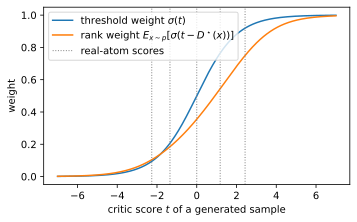

In [3]:
ts = np.linspace(-7.0, 7.0, 401)
w_thresh = sigma(ts)
w_rank = (p[:, None] * sigma(ts[None, :] - D_c[:, None])).sum(axis=0)
d2l.set_figsize((5.5, 3.2))
d2l.plt.plot(ts, w_thresh, label=r'threshold weight $\sigma(t)$')
d2l.plt.plot(ts, w_rank,
             label=r'rank weight $E_{x \sim p}[\sigma(t - D^\star(x))]$')
for i, v in enumerate(D_c):
    d2l.plt.axvline(v, ls=':', c='gray', lw=1,
                    label='real-atom scores' if i == 0 else None)
d2l.plt.xlabel('critic score $t$ of a generated sample')
d2l.plt.ylabel('weight')
d2l.plt.legend();

The curves differ as predicted. The threshold weight is a single sigmoid centered at zero, even though the pairing game does not determine that level. It exceeds 0.9 by the highest real score and is otherwise independent of the distribution of real scores. The rank weight instead changes across the dotted lines marking those scores, with each transition weighted by the corresponding mass $p(x)$. At the highest real score it is only about 0.75, so it still distinguishes samples that the threshold weight treats as nearly equivalent. The rank weight approaches one only when a generated sample outranks nearly the entire real population. Adding a constant to all critic scores changes the threshold weight but shifts both the generated and real scores equally, leaving the rank weight unchanged.

## Summary

The pairing objective the equation is the Bradley--Terry log-likelihood of ranking a real sample above a generated one. Because it depends only on score differences, the critic is identified up to an additive constant. The objective also depends on the distributions through $p \otimes q$, outside the affine framework of that section. Despite these changes, the optimal critic remains the log density ratio $\lambda$ up to a constant.

Lifting an ordered pair to a single observation turns the pairing objective into the log-loss game of that section between $p \otimes q$ and $q \otimes p$. Its calibrated value is therefore $d_{\mathrm{Rp}} = \mathrm{JS}(p \otimes q, q \otimes p)$, which measures how much information the ordered pair provides about the position of the real sample. It satisfies $\mathrm{JS}(p, q) \leq d_{\mathrm{Rp}} \leq \log 2$, equals twice $\mathrm{JS}$ locally near $q = p$, and reaches $\log 2$ on disjoint supports. Pairing thus preserves the support-saturation limitation of the classical game.

Pairing changes the generator's per-sample weight from a comparison with one threshold to a rank statistic over the real population. In finite-sample best-response analysis, this change removes mode-dropping local minima [@Sun.Fang.Schwing.2020]. The saturating and non-saturating variants nevertheless remain distinct. R3GAN states a zero-sum objective in the paper but uses the non-saturating generator update in its reference implementation, so reproducing the displayed minimax equation gives a different early-training update. The finite example verifies the closed form to nine decimal places and illustrates the two weights. This value analysis does not imply convergence of alternating gradient updates; that section analyzes that problem and introduces regularization that restores local convergence.

## Exercises

1. Prove the shift invariance $\Phi(D + b) = \Phi(D)$ for every constant $b$, and conclude that the pairing game identifies its critic only up to an additive constant. Then explain why the same cancellation fails for the value function the equation of that section: which of its two terms moves in which direction under the shift, and why does the trade-off strictly lower the value at the optimum?
1. Check the shift invariance numerically. On the five-atom example of the verification cell, add $b = 5$ to every entry of the recovered critic $D$ and recompute $\Phi$; confirm that the printed value is unchanged at machine precision. Then explain in one sentence why the same shift changes the value function the equation of that section.
1. Unequal ordering priors. Present the pair real-first with probability $\alpha \in (0, 1)$: with probability $\alpha$ the critic receives $(x, x')$ and otherwise $(x', x)$, with $x \sim p$ and $x' \sim q$, and a pair critic is scored by the log loss for predicting which presentation occurred. Derive the optimal pair critic, the Bayes log-odds $\lambda(a_1) - \lambda(a_2) + \log \frac{\alpha}{1 - \alpha}$, and show, by adapting the lifting lemma, that the value of the game is, up to constants, the skewed divergence $\alpha\, \mathrm{KL}(P \,\|\, m_\alpha) + (1 - \alpha)\, \mathrm{KL}(Q \,\|\, m_\alpha)$ with $P = p \otimes q$, $Q = q \otimes p$, and $m_\alpha = \alpha P + (1 - \alpha) Q$. Can a pure difference critic $D(a_1) - D(a_2)$ still attain the optimum, or does the prior force a bias term?
1. Local expansion. Let $q = p\,(1 + \epsilon h)$ with $E_p[h] = 0$ and $h$ bounded. Starting from the equation, write $u = \lambda(x') - \lambda(x)$ and expand $\log(1 + e^u) = \log 2 + \tfrac{u}{2} + \tfrac{u^2}{8} + O(u^4)$. Compute $E[u] = E_q[\lambda] - E_p[\lambda]$ and $E[u^2]$ to second order in $\epsilon$, and conclude $d_{\mathrm{Rp}} = \tfrac{\epsilon^2}{4} E_p[h^2] + O(\epsilon^3)$. Then apply the corresponding expansion to the entropy form the equation to show $\mathrm{JS}(p, q) = \tfrac{\epsilon^2}{8} E_p[h^2] + O(\epsilon^3)$, so that locally $d_{\mathrm{Rp}} = 2\, \mathrm{JS} + O(\epsilon^3)$.
1. More negatives. Draw $K$ real samples $x_1, \ldots, x_K \sim p$ and one generated sample $x' \sim q$, place all $K + 1$ samples in a uniformly random order, and ask the critic which position holds the generated one. Show that the Bayes posterior for position $j$ is the softmax $e^{-\lambda(a_j)} / \sum_k e^{-\lambda(a_k)}$, and, repeating the lifting argument with $K + 1$ hypotheses in place of two, that the value of the game is the generalized Jensen--Shannon divergence of the $K + 1$ product measures $P_j = p^{\otimes (j-1)} \otimes q \otimes p^{\otimes (K - j + 1)}$, namely $H\big[\tfrac{1}{K+1} \sum_j P_j\big] - K H[p] - H[q]$, with range $[0, \log(K + 1)]$. Use $H[P_j] = K H[p] + H[q]$. The softmax over negated log ratios and the $\log(K{+}1)$ ceiling are those of the InfoNCE bound of that section, with the generated sample as the odd one out that the softmax must identify.
1. Separability and the choice of loss. Replace the logistic payoff in the equation by a general concave payoff $\ell$, giving $\Phi_\ell(D) = E_{x \sim p,\, x' \sim q}[\ell(D(x) - D(x'))]$, and consider the corresponding two-sided game on the pair space, in which an unrestricted pair critic $\mathcal{D}$ collects $\ell(\mathcal{D})$ on pairs from $P = p \otimes q$ and $\ell(-\mathcal{D})$ on pairs from $Q = q \otimes p$. (a) Show that for every antisymmetric $\mathcal{D}$ the pair-space objective equals $2\, E_{P}[\ell(\mathcal{D})]$, which specializes to $2\, \Phi_\ell(D)$ when $\mathcal{D}$ is the difference critic built from $D$, and conclude that restricting to differences can only lower the supremum. (b) For the logistic payoff, verify that the unrestricted optimum $\log \frac{dP}{dQ} = \lambda(a_1) - \lambda(a_2)$ is a difference critic, so the restriction costs nothing. Identify the exact property of product measures the verification uses. (c) For the least-squares payoff, whose pointwise optimum reports the posterior $2\eta - 1$ with $\eta = \frac{P}{P + Q} = \sigma(\lambda(a_1) - \lambda(a_2))$, show that the optimal pair score $2\sigma(\lambda(a_1) - \lambda(a_2)) - 1 = \tanh\big(\tfrac{\lambda(a_1) - \lambda(a_2)}{2}\big)$ is not additively separable, and conclude that a relativistic least-squares game over difference critics optimizes a strict lower bound on its lifted divergence in general.

[Discussions](https://d2l.discourse.group/)